# Jev vs the trees

The three tree models learn from ~20,000 labelled rows of *these two babies*. [Jev](https://docs.typesafe.ai/introduction) learns nothing from us: it's a zero-shot model that reads text and answers yes/no questions with a probability. So each `val` row is turned into a short plain-English description of the baby's state, and Jev is asked "will she fall asleep within 30 / 60 minutes?". Its answers are scored with exactly the same metrics and charts as the trees, on exactly the same rows.

**Before running:** put `TYPESAFE_API_KEY=...` in `ml/.env`. That file is gitignored, and the key is read as a `SecretStr`, so it never appears in output.

**Cost:** about 420 input tokens per row, so the whole `val` split (4,390 rows, both questions in one call per row) is roughly 1.8M tokens, or about **$0.08**. Answers are cached in `ml/data/jev/`, so rerunning this notebook doesn't call the API again unless the questions or the state wording change.

In [1]:
%load_ext autoreload
%autoreload 2

import json

from baby_ml import Comparison, JevModel, example_states, load_training_set, metrics_table

df = load_training_set()
print(df.attrs["snapshot"], df.shape)

c:\Users\nikil\dbt-baby-data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ml_sleep_training_set_20260923T211259.parquet (28713, 63)


## What Jev sees

The arithmetic is done in code first (durations, the share of a typical wake window, above or below usual sleep), because Jev is documented as unreliable at maths and at comparing times. Read a few before spending anything: if a sentence would confuse a person, it'll confuse Jev too.

In [2]:
for state in example_states(df, n=3):
    print(json.dumps(state, indent=1))

{
 "baby": "21 weeks old (5.0 months)",
 "time_now": "13:10 (afternoon)",
 "current_wake_window": "Awake for 1 h 1 min, since waking from a nap that lasted 1 h 26 min. Her typical wake window over the last two weeks is 1 h 57 min, so she is 52% of the way through a typical wake window.",
 "recent_wake_windows": "Her last three wake windows averaged 2 h 14 min.",
 "today_so_far": "Up for the day for 4 h 55 min; 1 nap so far today totalling 1 h 26 min.",
 "last_night": "Slept 10 h 33 min in total, longest stretch 7 h 33 min, woke once.",
 "sleep_last_24h": "14 h 12 min across 4 sleeps, about her usual daily amount.",
 "feeding": "Last feed started 54 min ago (a 12 min breastfeed). 7 feeds in the last 24 hours, about every 3 h 35 min."
}
{
 "baby": "20 weeks old (4.6 months)",
 "time_now": "10:10 (morning)",
 "current_wake_window": "Awake for 15 min, since waking from a nap that lasted 31 min. Her typical wake window over the last two weeks is 1 h 46 min, so she is 14% of the way through 

## Smoke test: 20 rows

A few cents' worth, to check the key works and the probabilities look sensible. These rows are a random sample, so **don't compare these numbers to the trees**. `with_predictions` below refuses them for that reason.

In [5]:
jev = JevModel()
smoke = await jev.predict(df, "val", limit=20)
metrics_table(list(smoke.values())).round(3)

Asking Jev about 20 rows (0 cached)
  20 / 20


,,split,rows,base_rate,pr_auc,roc_auc,brier,brier_base_rate,mean_predicted
label,model,,,,,,,,
is_asleep_30_mins,jev,val,20,0.10,0.500,0.931,0.157,0.090,0.383
is_asleep_60_mins,jev,val,20,0.35,0.924,0.962,0.161,0.227,0.503


## The full val split

In [6]:
jev_preds = await jev.predict(df, "val")
jev.cost()

Asking Jev about 4,370 rows (20 cached)
  200 / 4,370
  400 / 4,370
  600 / 4,370
  800 / 4,370
  1,000 / 4,370
  1,200 / 4,370
  1,400 / 4,370
  1,600 / 4,370
  1,800 / 4,370
  2,000 / 4,370
  2,200 / 4,370
  2,400 / 4,370
  2,600 / 4,370
  2,800 / 4,370
  3,000 / 4,370
  3,200 / 4,370
  3,400 / 4,370
  3,600 / 4,370
  3,800 / 4,370
  4,000 / 4,370
  4,200 / 4,370
  4,370 / 4,370


{'rows': 4390, 'input_tokens': 2927404, 'usd': 0.12295096800000001}

## Side by side

The trees are the same untuned models as in `01_explore`. Jev is added to the same `Comparison`, so every metric and curve shows all four.

In [7]:
comparison = Comparison.run(df, split="val").with_predictions(list(jev_preds.values()))
comparison.metrics().round(3)

split  rows  base_rate  pr_auc  roc_auc  \
label             model                                                   
is_asleep_30_mins lightgbm        val  4390      0.222   0.567    0.850   
                  xgboost         val  4390      0.222   0.582    0.853   
                  random_forest   val  4390      0.222   0.520    0.838   
is_asleep_60_mins lightgbm        val  4390      0.426   0.774    0.865   
                  xgboost         val  4390      0.426   0.773    0.865   
                  random_forest   val  4390      0.426   0.761    0.859   
is_asleep_30_mins jev             val  4390      0.222   0.535    0.811   
is_asleep_60_mins jev             val  4390      0.426   0.776    0.839   

                                 brier  brier_base_rate  mean_predicted  
label             model                                                  
is_asleep_30_mins lightgbm       0.138            0.173           0.311  
                  xgboost        0.136            0.173           0.301  
                  random_forest  0.139            0.173           0.310  
is_asleep_60_mins lightgbm       0.162            0.245           0.545  
                  xgboost        0.163            0.245           0.548  
                  random_forest  0.165            0.245           0.534  
is_asleep_30_mins jev            0.148            0.173           0.342  
is_asleep_60_mins jev            0.180            0.245           0.491

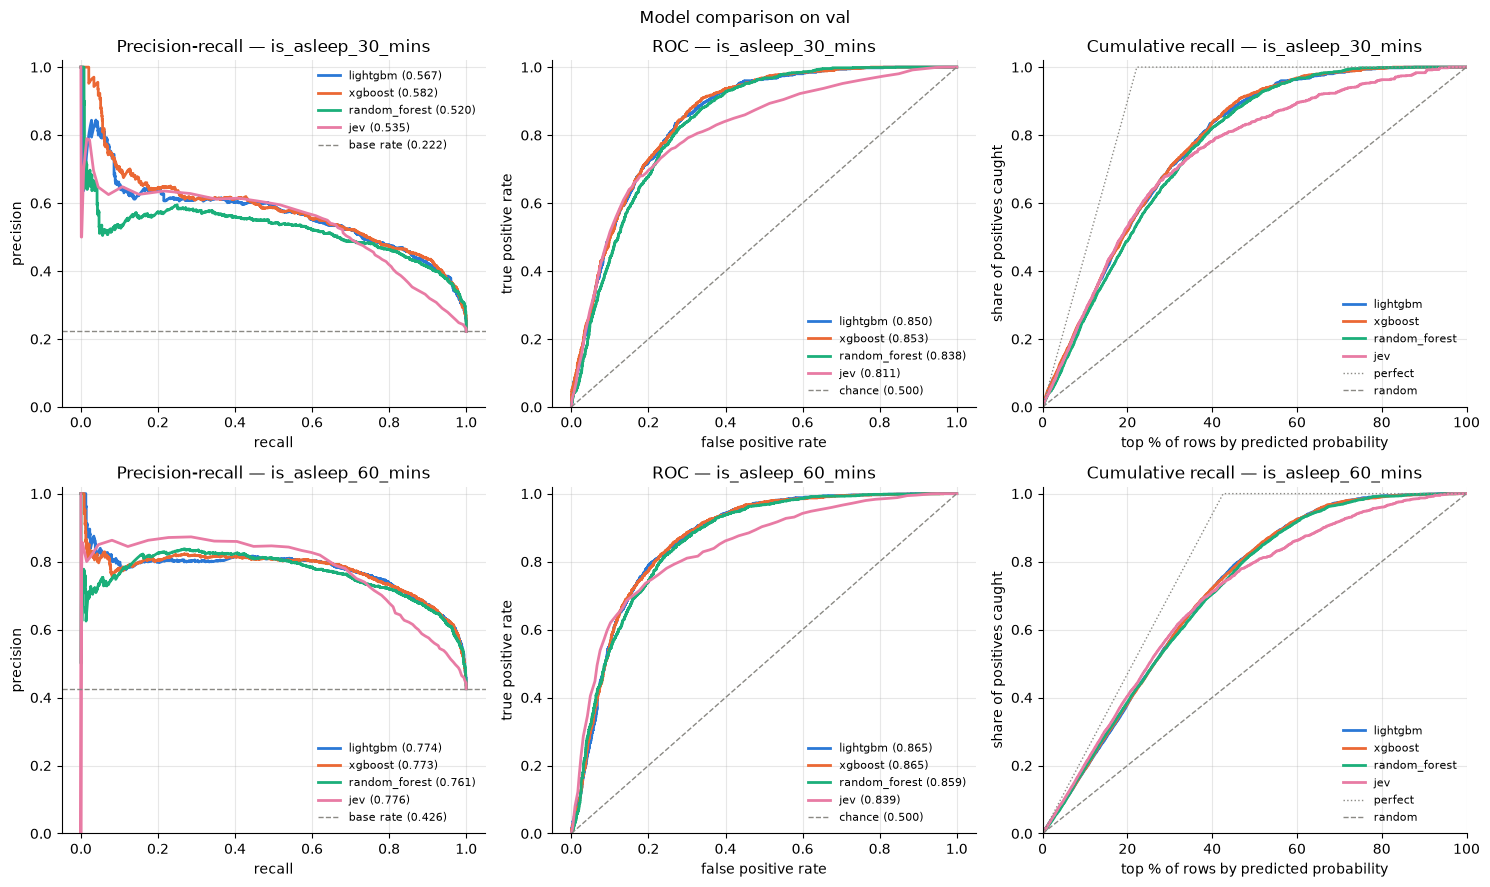

In [8]:
comparison.plot_performance();

In [9]:
comparison.recall_at_percentiles().round(3)

top 5%  top 10%  top 20%  top 30%  top 50%
label             model                                                    
is_asleep_30_mins lightgbm        0.137    0.275    0.519    0.703    0.921
                  xgboost         0.151    0.278    0.519    0.704    0.925
                  random_forest   0.124    0.263    0.488    0.671    0.912
is_asleep_60_mins lightgbm        0.094    0.189    0.379    0.567    0.836
                  xgboost         0.090    0.189    0.381    0.566    0.837
                  random_forest   0.088    0.193    0.387    0.560    0.828
is_asleep_30_mins jev             0.139    0.282    0.532    0.685    0.840
is_asleep_60_mins jev             0.099    0.204    0.404    0.584    0.798

### Reading it

- **Base rate first.** On `val`, 22% of rows are followed by sleep within 30 minutes and 43% within 60. A PR-AUC at the base rate, or a ROC-AUC near 0.5, means no skill.
- **`mean_predicted` against `base_rate`** shows over- or under-confidence. The trees run at about 0.30 against 0.22. Jev has never seen these babies, so it has no idea of their base rate, and its offset could go either way.
- **Brier against `brier_base_rate`** is the honest single number for probabilities. Beating the base-rate Brier means the probabilities are useful as they stand, not just the ranking.